In [20]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load and split (80/20 stratified)


In [21]:
iris = datasets.load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Shapes: X_train", X_train.shape, "X_test", X_test.shape)
print("Class distribution in y_train:", np.bincount(y_train))
print("Class distribution in y_test:", np.bincount(y_test))

Shapes: X_train (120, 4) X_test (30, 4)
Class distribution in y_train: [40 40 40]
Class distribution in y_test: [10 10 10]


# Train Decision Tree and extract feature importances



Feature importances (Decision Tree):
          feature  importance
petal length (cm)    0.558568
 petal width (cm)    0.406015
 sepal width (cm)    0.029167
sepal length (cm)    0.006250


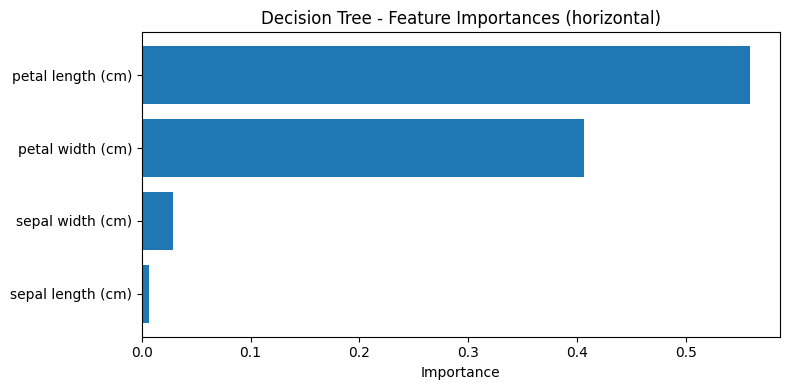

In [22]:
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
importances = dt.feature_importances_

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=True)

print("\nFeature importances (Decision Tree):")
print(fi_df.sort_values("importance", ascending=False).to_string(index=False))

# Plot horizontal bar chart of feature importances
plt.figure(figsize=(8,4))
plt.barh(fi_df["feature"], fi_df["importance"])
plt.xlabel("Importance")
plt.title("Decision Tree - Feature Importances (horizontal)")
plt.tight_layout()
plt.show()


# Confusion matrix for the Decision Tree (using this DT as 'best' model here)



Classification report (Decision Tree on test):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



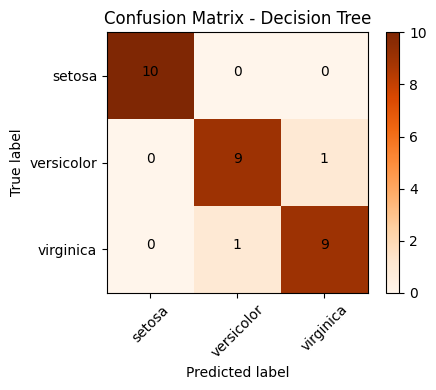

In [23]:
y_pred_dt = dt.predict(X_test)
cm = confusion_matrix(y_test, y_pred_dt)

print("\nClassification report (Decision Tree on test):")
print(classification_report(y_test, y_pred_dt, target_names=target_names))

plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Oranges)
plt.title("Confusion Matrix - Decision Tree")
plt.colorbar()
tick_marks = np.arange(len(target_names))
plt.xticks(tick_marks, target_names, rotation=45)
plt.yticks(tick_marks, target_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], horizontalalignment="center", color="black")
plt.tight_layout()
plt.show()


# KNN: accuracy vs k (1..20). Use scaling.



KNN accuracy by k (1..20):
 k  accuracy
 1  0.966667
 2  0.933333
 3  0.933333
 4  0.933333
 5  0.933333
 6  0.933333
 7  0.966667
 8  0.933333
 9  0.966667
10  0.966667
11  0.966667
12  0.966667
13  0.966667
14  0.966667
15  0.966667
16  0.966667
17  0.966667
18  0.966667
19  0.966667
20  0.966667


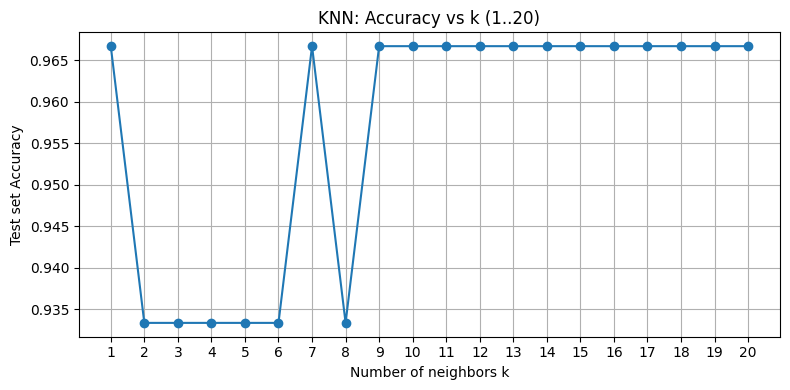

In [24]:
knn_scores = []
ks = list(range(1, 21))
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    knn_scores.append(acc)

knn_df = pd.DataFrame({"k": ks, "accuracy": knn_scores})
print("\nKNN accuracy by k (1..20):")
print(knn_df.to_string(index=False))

plt.figure(figsize=(8,4))
plt.plot(knn_df["k"], knn_df["accuracy"], marker='o')
plt.xlabel("Number of neighbors k")
plt.ylabel("Test set Accuracy")
plt.title("KNN: Accuracy vs k (1..20)")
plt.xticks(ks)
plt.grid(True)
plt.tight_layout()
plt.show()

# Decision Tree: train and test accuracy vs max_depth (1..10)



Decision Tree accuracy by max_depth (1..10):
 max_depth  train_accuracy  test_accuracy
         1        0.666667       0.666667
         2        0.966667       0.933333
         3        0.983333       0.966667
         4        0.991667       0.933333
         5        1.000000       0.933333
         6        1.000000       0.933333
         7        1.000000       0.933333
         8        1.000000       0.933333
         9        1.000000       0.933333
        10        1.000000       0.933333


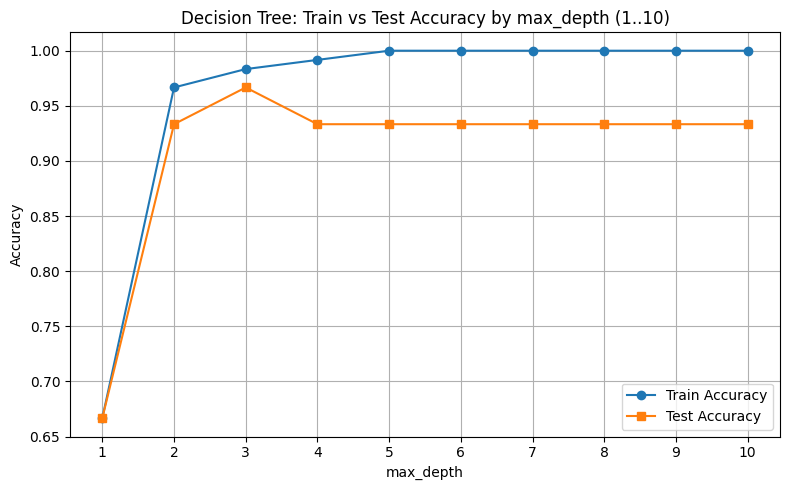

In [25]:
depths = list(range(1, 11))
train_acc = []
test_acc = []

for d in depths:
    dt_d = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    dt_d.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, dt_d.predict(X_train)))
    test_acc.append(accuracy_score(y_test, dt_d.predict(X_test)))

dt_depth_df = pd.DataFrame({
    "max_depth": depths,
    "train_accuracy": train_acc,
    "test_accuracy": test_acc
})
print("\nDecision Tree accuracy by max_depth (1..10):")
print(dt_depth_df.to_string(index=False))

plt.figure(figsize=(8,5))
plt.plot(dt_depth_df["max_depth"], dt_depth_df["train_accuracy"], marker='o', label="Train Accuracy")
plt.plot(dt_depth_df["max_depth"], dt_depth_df["test_accuracy"], marker='s', label="Test Accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Train vs Test Accuracy by max_depth (1..10)")
plt.xticks(depths)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Summary tables


In [26]:
summary_table = pd.DataFrame({
    "model": ["DecisionTree"] + ["KNN"],
    "note": ["Vanilla DT (no max_depth limit)"] + ["KNN (k tuned via 1..20)"]
})
 
print("\nSummary tables prepared.")

# Display small reports / helpful arrays
print("\nConfusion matrix (as array):\n", cm)
print("\nBest K for KNN (highest accuracy):")
best_k = knn_df.iloc[knn_df['accuracy'].idxmax()]
print(best_k.to_dict())

best_depth_idx = dt_depth_df['test_accuracy'].idxmax()
best_depth_row = dt_depth_df.iloc[best_depth_idx]
print("\nBest max_depth (by test accuracy):", best_depth_row.to_dict())

# Provide short textual conclusions (printed here for convenience)
conclusions = """
Conclusions (automatic summary):
1) Feature importances from the Decision Tree show which features the tree used most for splitting.
   You can see numeric importances printed above. Typically, petal length and petal width are most influential for Iris.
2) Confusion matrix: inspect which classes are confused. On Iris, versicolor and virginica are sometimes mixed.
3) KNN behavior (k from 1..20): small k may overfit (high variance), large k smooths decisions and may underfit.
   The printed table shows accuracy per k and the plotted curve visualizes stability and the optimal small range.
4) Decision Tree depth: as depth increases, training accuracy typically rises and test accuracy may peak then drop if overfitting.
   The plotted train/test curves help pick the depth with the best balance (underfitting vs overfitting).
"""
print(conclusions)


Summary tables prepared.

Confusion matrix (as array):
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Best K for KNN (highest accuracy):
{'k': 1.0, 'accuracy': 0.9666666666666667}

Best max_depth (by test accuracy): {'max_depth': 3.0, 'train_accuracy': 0.9833333333333333, 'test_accuracy': 0.9666666666666667}

Conclusions (automatic summary):
1) Feature importances from the Decision Tree show which features the tree used most for splitting.
   You can see numeric importances printed above. Typically, petal length and petal width are most influential for Iris.
2) Confusion matrix: inspect which classes are confused. On Iris, versicolor and virginica are sometimes mixed.
3) KNN behavior (k from 1..20): small k may overfit (high variance), large k smooths decisions and may underfit.
   The printed table shows accuracy per k and the plotted curve visualizes stability and the optimal small range.
4) Decision Tree depth: as depth increases, training accuracy typically rises and test accuracy may pea